In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
# Вычисляемые поля и условия
# Векторные операции
# np.where
# np.select
# apply (column)
# apply (row)

In [3]:
df = pd.read_csv('../data/raw/Students Social Media Addiction.csv')

In [4]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [10]:
# Векторные операции
df['Avg_Daily_Usage_Minutes'] = df['Avg_Daily_Usage_Hours'] * 60
df['Sleep_Minutes_Per_Night'] = df['Sleep_Hours_Per_Night'] * 60

In [11]:
# Векторные операции
df['usage_to_sleep'] = df['Avg_Daily_Usage_Minutes'] / df['Sleep_Minutes_Per_Night']

In [12]:
df[['Avg_Daily_Usage_Minutes', 'Sleep_Minutes_Per_Night', 'usage_to_sleep']]

,Avg_Daily_Usage_Minutes,Sleep_Minutes_Per_Night,usage_to_sleep
0,312.0,390.0,0.800000
1,126.0,450.0,0.280000
2,360.0,300.0,1.200000
3,180.0,420.0,0.428571
4,270.0,360.0,0.750000
...,...,...,...
700,282.0,432.0,0.652778
701,408.0,354.0,1.152542
702,336.0,402.0,0.835821
703,258.0,450.0,0.573333


In [14]:
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    249
TikTok       154
Facebook     123
WhatsApp      54
Twitter       30
LinkedIn      21
WeChat        15
Snapchat      13
VKontakte     12
LINE          12
KakaoTalk     12
YouTube       10
Name: count, dtype: int64

In [64]:
def classify_platform(platform):
    if platform in ('Instagram', 'TikTok', 'Snapchat', 'YouTube'):
        return 'media_platfrom'
    elif platform in ('Facebook', 'Twitter', 'LinkedIn', 'VKontakte'):
        return 'social_network'
    elif platform in ('WhatsApp', 'WeChat', 'LINE', 'KakaoTalk'):
        return 'messenger'
    else:
        return None
    

In [65]:
df['Type_Platform'] = df['Most_Used_Platform'].apply(classify_platform)

In [66]:
df[['Most_Used_Platform', 'Type_Platform']]

,Most_Used_Platform,Type_Platform
0,Instagram,media_platfrom
1,Twitter,social_network
2,TikTok,media_platfrom
3,YouTube,media_platfrom
4,Facebook,social_network
...,...,...
700,TikTok,media_platfrom
701,Instagram,media_platfrom
702,WeChat,messenger
703,Twitter,social_network


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
 13  Avg_D

In [67]:
df['Sleep_Quality'] = np.where(
    df['Sleep_Hours_Per_Night'] >= 6, # Условие
    'normal_sleep', # Значение если True
    'lack_of_sleep' # Значение если False
)

In [68]:
df[['Sleep_Hours_Per_Night', 'Sleep_Quality']]

,Sleep_Hours_Per_Night,Sleep_Quality
0,6.5,normal_sleep
1,7.5,normal_sleep
2,5.0,lack_of_sleep
3,7.0,normal_sleep
4,6.0,normal_sleep
...,...,...
700,7.2,normal_sleep
701,5.9,lack_of_sleep
702,6.7,normal_sleep
703,7.5,normal_sleep


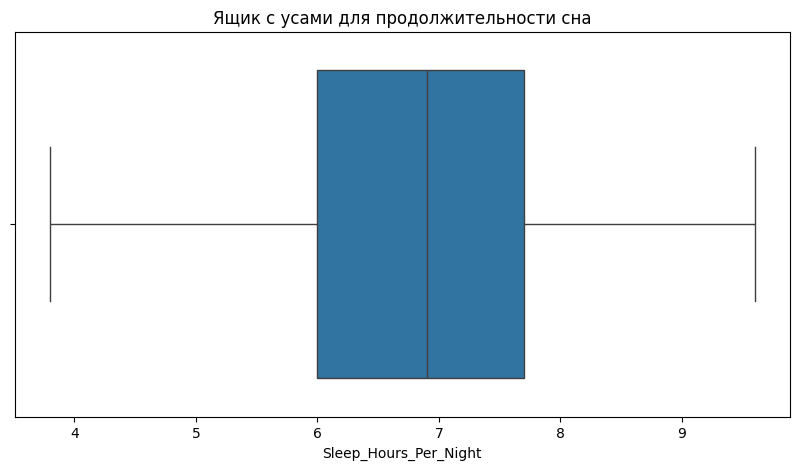

In [32]:
plt.figure(figsize=(10,5)) # Размер рисунка
plt.title('Ящик с усами для продолжительности сна') # Заголовок
sns.boxplot(df, x="Sleep_Hours_Per_Night")
plt.show() # Показать график

In [69]:
conditions = [
    df['Sleep_Hours_Per_Night'] > 9,
    df['Sleep_Hours_Per_Night'] >= 6,
]

choices = [
    'a_lot_of_sleep',
    'normal_sleep',
]

df['Sleep_Quality_2'] = np.select(
    conditions, # Спсиок условий
    choices,  # Список ответов
    default='lack_of_sleep' # По умолчанию (else) [Меньше 6 часов]
)

In [72]:
df[['Sleep_Hours_Per_Night', 'Sleep_Quality', 'Sleep_Quality_2']].sort_values('Sleep_Hours_Per_Night')

,Sleep_Hours_Per_Night,Sleep_Quality,Sleep_Quality_2
496,3.8,lack_of_sleep,lack_of_sleep
486,3.9,lack_of_sleep,lack_of_sleep
476,4.0,lack_of_sleep,lack_of_sleep
466,4.1,lack_of_sleep,lack_of_sleep
219,4.1,lack_of_sleep,lack_of_sleep
...,...,...,...
481,9.4,normal_sleep,a_lot_of_sleep
474,9.4,normal_sleep,a_lot_of_sleep
484,9.5,normal_sleep,a_lot_of_sleep
491,9.5,normal_sleep,a_lot_of_sleep


In [40]:
# Average_Health_Type
# Mental_Health_Score >= 6 & Addicted_Score <= 4 : Health
# else: Warning

In [ ]:
# and и &
# or или | 

In [73]:
df['Average_Health_Type'] = np.where(
    (df['Mental_Health_Score'] >= 6) & (df['Addicted_Score'] <= 4),
    'Health', 
    'Warning'
)

In [74]:
df[['Mental_Health_Score', 'Addicted_Score', 'Average_Health_Type']]

,Mental_Health_Score,Addicted_Score,Average_Health_Type
0,6,8,Warning
1,8,3,Health
2,5,9,Warning
3,7,4,Health
4,6,7,Warning
...,...,...,...
700,7,5,Warning
701,4,9,Warning
702,6,7,Warning
703,8,4,Health


In [54]:
def calculate_health_type(row):
    if (row['Mental_Health_Score'] >= 6) & (row['Addicted_Score'] <= 4):
        return 'Health'
    else:
        return 'Warning'

In [56]:
df['Average_Health_Type_2'] = df.apply(calculate_health_type, axis=1)

In [57]:
df[['Mental_Health_Score', 'Addicted_Score', 'Average_Health_Type', 'Average_Health_Type_2']]

,Mental_Health_Score,Addicted_Score,Average_Health_Type,Average_Health_Type_2
0,6,8,Warning,Warning
1,8,3,Health,Health
2,5,9,Warning,Warning
3,7,4,Health,Health
4,6,7,Warning,Warning
...,...,...,...,...
700,7,5,Warning,Warning
701,4,9,Warning,Warning
702,6,7,Warning,Warning
703,8,4,Health,Health
